<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK11_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

필사 범위: 딥러닝 파이토치 교과서 ch5. 1p.166~179

# 5. 합성곱 신경망 I

## 5.1 합성곱 신경망
- 이미지 전체를 한 번에 계산하는 것이 아닌 이미지의 국소적 부분을 계산함으로써 시간과 자원을 절약하여 이미지의 세밀한 부분까지 분석할 수 있는 신경망



### 5.1.1 합성곱층의 필요성
- 이미지나 영상을 처리하는 데 유용
- 이미지 분석은 배열을 펼쳐서 각 픽셀에 가중치를 곱해 은닉층으로 전달하게 됨. 하지만 이는 데이터의 공간적 구조를 무시하게 되기에 합성곱층을 도입해 이를 방지함.




### 5.1.2 합성곱 신경망 구조 (Convolutional Neural Network, CNN 또는 ConvNet)

- 음성 인식이나 이미지/영상 인식에서 주로 사용되는 신경망.
- 다차원 배열 데이터를 처리하도록 구성되어 컬러 이미지 같은 다차원 배열 처리에 특화
- 계층 다섯 개로 구성
  1. 입력층
  2. 합성곱층
  3. 풀링층
  4. 완전연결층
  5. 출력층

  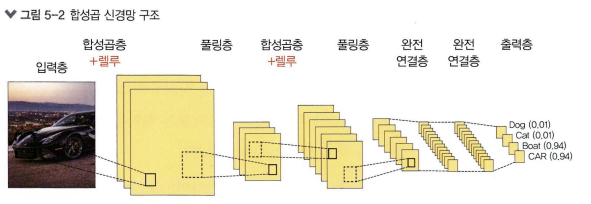

- **합성곱층과 풀링층**을 거치면서 입력 이미지의 주요 특성 벡터(feature vector)를 추출 > **완전연결층**을 거치면서 1차원 벡터로 변환 > **출력층**에서 확성화 함수인 소프트맥스(softmax) 함수를 사용하여 최종 결과가 출력

#### 입력층
- 입력 이미지 데이터가 최초로 거치게 되는 계층
  - 이미지: 단순 1차원의 데이터가 아닌 높이, 너비, 채널의 값을 갖는 3차원 데이터 (그레이스케일이면 1, 컬러면 3 값을 가짐)

#### 합성곱층
- 입력 데이터에서 **특성을 추출**하는 역할을 수행
  - 특성 추출 방법
 : 이미지에 대한 특성을 감지하기 위해 커널(kernel)이나 필터를 사용. 커널/필터는 이미지의 모든 영역을 훑으면서 특성을 추출 > 특성 맵(feature map)이 추출됨.
- 커널은 3x3, 5x5 크기로 적용되는 것이 일반적, 스트라이드(stride)라는 지정된 간격에 따라 순차적으로 이동.
- 스트라이드가 1일 때 이동하는 과정 (이미지 크기가 (6,6,1)이며 3x3크기의 커널/필터가 스트라이드 1간격으로 이동하며 합성곱 연산을 수행하는 과정)
  1. 입력 이미지에 3x3 필터 적용
    - 입력 이미지와 필터를 포개 놓고 대응되는 숫자끼리 곱한 후 모두 더함
  2. 필터가 1만큼 이동
  3. 필터가 1만큼 두 번째 이동
  4. 필터가 1만큼 세 번째 이동
  5. 필터가 1만큼 네 번째 이동
  6. 필터가 1만큼 마지막으로 이동
- 그레이스케일 이미지와 구분되는 특징
  1. 필터 채널이 3이라는 것
  2. RGB 각각에 서로 다른 가중치로 합성곱을 적용한 후 결과를 더해줌
  그 외 스트라이드 및 연산하는 방법은 동일, <br>
  but, 필터 채널은 **3**이지만, 필터 개수는 **한 개**

- 필터가 두 개 이상인 합성곱의 형태<br>
  그림

  합성곱층 요약
  - 입력 데이터
  - 하이퍼파라미터
  - 출력 데이터


#### 풀링층
- 합성곱층과 유사하게 특성 맵의 차원을 다운 샘플링하여 연산량을 감소시키고, 주요한 특성 벡터를 추출하여 학습을 효과적으로 할 수 있게 함.
  - 다운샘플링: 이미지를 축소하는 것
- 풀링 연산에 사용되는 두 가지
  - 최대 풀링(max pooling): 대상 영역에서 최댓값을 추출
  - 평균 풀링(average pooling): 대상 영역에서 평균을 반환<br>
  대부분의 합성곱 신경망에서는 최대 풀링이 사용됨. 평균 풀링은 각 커널 값을 평균화 시켜 중욯나 가중치를 갖는 값의 특성이 희미해질 수 있기 때문.

  - 최대 풀링 연산 과정
    1. 최대 풀링 과정
    2. 최대 풀링 과정
    3. 최대 풀링 과정
    4. 최대 풀링 과정
- 풀링의 사용 파라미터
  - 입력 데이터
  - 하이퍼 파라미터
  - 출력 데이터


#### 완전 연결층
- 합성곱층과 풀링층을 거치며 차원이 축소된 특성맵이 완전 연결층(fully connected layer)으로 전달.
  - 이 과정에서 이미지는 3차원 벡터에서 1차원 벡터로 펼쳐지게(flatten) 됨.

  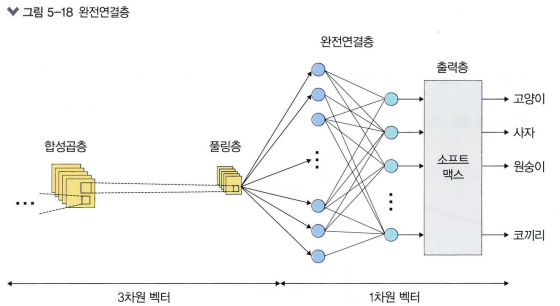

#### 출력층
- 소프트맥스 활성화 함수가 사용됨.
- 입력받은 값을 0~1 사이의 값으로 출력
- 마지막 출력층의 소프트맥스 함수를 사용하여 각 레이블에 속할 확률 값이 출력 > 가장 높은 확률 값을 갖는 레이블이 최종 값으로 선정.




### 5.1.3 1D, 2D, 3D 합성곱
- 이동하는 방향의 수와 출력 형태에 따라 1D, 2D, 3D로 분류할 수 있음.

#### 1D 합성곱
- 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱.
- 입력(W)과 필터(k)에 대한 출력은 W가 됨.

#### 2D 합성곱
- 필터가 다음 그림과 같이 방향 두 개로 움직이는 형태.
- 입력(W, H)과 필터(k, k)에 대한 출력은 (W, H)가 되며 출력 형태는 2D 행렬이 됨.

#### 3D 합성곱
- 필터가 움직이는 방향이 세 개 있음.
- 입력(W, H, L)에 대해 필터(k, k, d)를 적용하면 출력으로 (W, H, L)을 갖는 형태가 3D 합성곱.
- d < L을 유지하는 것이 중요!

#### 3D 입력을 갖는 2D 합성곱
- 3D 형태임에도 출력 형태가 3D가 아닌 2D 행렬을 취하는 것
- 필터에 대한 길이(L)가 입력 채널의 길이(L)와 같아야 함.
- 입력(W, H, L)에 필터 (k, k, L)을 적용하면 출력은 (W, H)가 됨.
- LeNet-5와 VGG가 3D 입력을 갖는 2D 합성곱의 대표적 사례

#### 1x1 합성곱
- 3D 형태로 입력됨.
- 입력(W, H, L)에 필터(1, 1, L)를 적용하면 출력은 (W, H)가 됨.
- 채널 수를 조정해서 연산량이 감소되는 효과가 있음.